In [1]:
import pandas as pd

# Load retracted papers metadata
retracted_papers = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retraction_watch.csv")

# Load country publication data
country_publications = pd.read_csv(r"C:\Users\Parsa\Downloads\scimagojr country rank 1996-2023 (1).csv")

# Define search terms
search_terms = ['computer science', 'data science', 'engineering -electrical']

# Filter retracted papers by subject
def filter_retracted_papers(df, search_terms):
    return df[df['Subject'].str.contains('|'.join(search_terms), case=False, na=False)]

filtered_retracted = filter_retracted_papers(retracted_papers, search_terms)

# Count retracted papers per country
retracted_counts = filtered_retracted['Country'].value_counts().rename_axis('Country').reset_index(name='Retracted_Count')



In [2]:
retracted_counts

,Country,Retracted_Count
0,China,6204
1,India,997
2,Iran,105
3,China;South Korea,96
4,Unknown,92
...,...,...
567,China;Iraq,1
568,Brazil;Egypt;India,1
569,Norway;Pakistan;South Korea,1
570,China;Mexico,1


In [3]:
import pandas as pd

# Load retracted papers metadata
retracted_papers = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retraction_watch.csv")

# Load country publication data
country_publications = pd.read_csv(r"C:\Users\Parsa\Downloads\scimagojr country rank 1996-2023 (1).csv")

# Define search terms
search_terms = ['computer science', 'data science', 'engineering -electrical']

# Filter retracted papers by subject
def filter_retracted_papers(df, search_terms):
    return df[df['Subject'].str.contains('|'.join(search_terms), case=False, na=False)]

filtered_retracted = filter_retracted_papers(retracted_papers, search_terms)

# Expand multiple-country entries
filtered_retracted['Country'] = filtered_retracted['Country'].str.split(';')
filtered_retracted = filtered_retracted.explode('Country')
filtered_retracted['Country'] = filtered_retracted['Country'].str.strip()

# Count retracted papers per country
retracted_counts = filtered_retracted['Country'].value_counts().rename_axis('Country').reset_index(name='Retracted_Count')

C:\Users\Parsa\AppData\Local\Temp\ipykernel_5204\913676314.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_retracted['Country'] = filtered_retracted['Country'].str.split(';')


In [4]:
retracted_counts

,Country,Retracted_Count
0,China,6817
1,India,1405
2,Saudi Arabia,352
3,United States,253
4,South Korea,211
...,...,...
108,Liberia,1
109,Armenia,1
110,Maldives,1
111,Eritrea,1


In [6]:
# Rename 'Document' column to match easier reference
country_publications.rename(columns={'Documents': 'Total_Publications'}, inplace=True)

# Merge with country publication data
merged_data = retracted_counts.merge(country_publications[['Country', 'Total_Publications']], on='Country', how='left')

# Calculate retraction rate
merged_data['Retraction_Rate'] = merged_data['Retracted_Count'] / merged_data['Total_Publications']

# Save results
merged_data.to_csv('retraction_rate_by_country.csv', index=False)

print(merged_data.head())

         Country  Retracted_Count  Total_Publications  Retraction_Rate
0          China             6817          10372322.0         0.000657
1          India             1405           2970196.0         0.000473
2   Saudi Arabia              352            419090.0         0.000840
3  United States              253          16047770.0         0.000016
4    South Korea              211           1604519.0         0.000132


In [9]:
import pandas as pd
from collections import Counter

# Load the CSV file (Ensure delimiter is correctly parsed)
df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retraction_watch.csv")  # Adjust delimiter if needed

# Extract and clean the "Country" column
country_list = df["Country"].dropna().str.split(";").explode().str.strip()

# Count occurrences
country_counts = Counter(country_list)

# Convert to DataFrame for better display
country_counts_df = pd.DataFrame(country_counts.items(), columns=["Country", "Count"]).sort_values(by="Count", ascending=False)

In [10]:
country_counts_df

,Country,Count
0,China,32474
18,United States,6771
17,India,4310
31,Russia,2726
13,United Kingdom,1867
...,...,...
132,St. Kitts & Nevis,1
131,Sint Maarten,1
107,Faroe Islands,1
125,Liberia,1


In [11]:
# Load the CSV file (Ensure delimiter is correctly parsed)
df = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retraction_watch.csv")  # Adjust delimiter if needed

# Extract and clean the "Country" column
country_list = df["Country"].dropna().str.split(";").explode().str.strip()

country_list.value_counts()

Country
China                32474
United States         6771
India                 4310
Russia                2726
United Kingdom        1867
                     ...  
St. Kitts & Nevis        1
Sint Maarten             1
Faroe Islands            1
Liberia                  1
Cayman Islands           1
Name: count, Length: 182, dtype: int64

In [12]:
df['Country'].value_counts()

Country
China                                                     29684
United States                                              4022
India                                                      2994
Russia                                                     2487
Japan                                                      1330
                                                          ...  
India;Iraq;Uzbekistan                                         1
Ecuador;Germany                                               1
Egypt;Pakistan;Saudi Arabia;South Africa;United States        1
Bangladesh;Italy                                              1
Egypt;Netherlands;Saudi Arabia                                1
Name: count, Length: 2653, dtype: int64

In [14]:
import pandas as pd

# Load retracted papers metadata
retracted_papers = pd.read_csv(r"C:\Users\Parsa\OneDrive\Documents\Internship\Sadegh Suleimani Internship\Web Confrence\Files\retraction_watch.csv")

# Load country publication data
country_publications = pd.read_csv(r"C:\Users\Parsa\Downloads\scimagojr country rank 1996-2023 (1).csv")

# Define search terms
search_terms = ['computer science', 'data science', 'engineering -electrical']

# Filter retracted papers by subject
def filter_retracted_papers(df, search_terms):
    return df[df['Subject'].str.contains('|'.join(search_terms), case=False, na=False)]

filtered_retracted = filter_retracted_papers(retracted_papers, search_terms)

# Expand multiple-country entries
filtered_retracted['Country'] = filtered_retracted['Country'].str.split(';')
filtered_retracted = filtered_retracted.explode('Country')
filtered_retracted['Country'] = filtered_retracted['Country'].str.strip()

# Count retracted papers per country
retracted_counts = filtered_retracted['Country'].value_counts().rename_axis('Country').reset_index(name='Retracted_Count')

C:\Users\Parsa\AppData\Local\Temp\ipykernel_33060\913676314.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_retracted['Country'] = filtered_retracted['Country'].str.split(';')


In [9]:
filtered_retracted[filtered_retracted['Country'].str.contains('China', case=False, na=False)]

,Record ID,Title,Subject,Institution,Journal,Publisher,Country,Author,URLS,ArticleType,RetractionDate,RetractionDOI,RetractionPubMedID,OriginalPaperDate,OriginalPaperDOI,OriginalPaperPubMedID,RetractionNature,Reason,Paywalled,Notes
0,61287,Basketball Object Extraction Method Based on I...,(B/T) Computer Science;(B/T) Data Science;(B/T...,"College of Physical Education, Jilin Universit...",Security and Communication Networks,Hindawi,China,Huachen Zhu;Long Liu,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,10/18/2023 0:00,10.1155/2023/9845748,0.0,8/29/2022 0:00,10.1155/2022/3021682,0.0,Retraction,+Concerns/Issues About Data;+Concerns/Issues A...,No,NaN
1,61270,Application of Image Processing Sensor and Pat...,(B/T) Business - Manufacturing;(B/T) Computer ...,School of Electronic and Information Engineeri...,Journal of Sensors,Hindawi,China,Qinghong Wu;Minghui Zhu,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,10/18/2023 0:00,10.1155/2023/9861989,0.0,7/1/2022 0:00,10.1155/2022/7924982,0.0,Retraction,+Concerns/Issues About Data;+Concerns/Issues A...,No,See also: https://pubpeer.com/publications/DD8...
2,61269,Application of Digital Image Processing Techno...,(B/T) Business - Manufacturing;(B/T) Computer ...,"School of Art and Design, Fuzhou University of...",Security and Communication Networks,Hindawi,China,Jhan Rong Shih,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,10/18/2023 0:00,10.1155/2023/9874672,0.0,8/17/2022 0:00,10.1155/2022/7971811,0.0,Retraction,+Concerns/Issues About Data;+Concerns/Issues A...,No,See also: https://pubpeer.com/publications/337...
3,61268,Application of CNN-Based Machine Learning in t...,(B/T) Business - Manufacturing;(B/T) Computer ...,College of Intelligent Systems Science and Eng...,Computational Intelligence and Neuroscience,Hindawi,China,Xiuyan Peng;Lunpan Wei;Wei Gao,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,10/18/2023 0:00,10.1155/2023/9843832,37886378.0,9/5/2022 0:00,10.1155/2022/9635251,36105635.0,Retraction,+Concerns/Issues About Data;+Concerns/Issues A...,No,See also: https://pubpeer.com/publications/141...
4,61267,Application of Capital Asset Pricing Model Bas...,(B/T) Business - Economics;(B/T) Computer Scie...,"School of Finance and Economics, Shenzhen Inst...",Computational Intelligence and Neuroscience,Hindawi,China,Guojing Geng;Zhigui Guan,https://retractionwatch.com/2022/09/28/exclusi...,Research Article;,10/18/2023 0:00,10.1155/2023/9874149,37886385.0,8/22/2022 0:00,10.1155/2022/5654271,36045975.0,Retraction,+Concerns/Issues About Data;+Concerns/Issues A...,No,See also: https://pubpeer.com/publications/735...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57021,3796,Prediction of posttranslational modification s...,(B/T) Computer Science;(BLS) Biochemistry;(BLS...,"Department of Applied Mathematics, College of ...",Journal of Computational Chemistry,Wiley,China,Xiaobo Wang;Yongcui Wang;Yingjie Tian;Xiaojian...,http://retractionwatch.com/2012/06/05/computat...,Research Article;,6/30/2012 0:00,10.1002/jcc.21526,22581607.0,4/21/2010 0:00,10.1002/jcc.21526,22581607.0,Retraction,+Error in Analyses;+Error in Results and/or Co...,No,Original Paper and RN share PMID and DOI
57846,2948,Improving the efficiencies of simultaneous org...,(B/T) Computer Science;(ENV) Ground/Surface Wa...,School of Materials Science & Chemical Enginee...,Water Research,Elsevier,China,Zhao-Bo Chen;Shu-Kai Nie;Nan-Qi Ren;Zhi-Qiang ...,http://retractionwatch.com/2012/11/09/how-does...,Research Article;,2/1/2013 0:00,10.1016/j.watres.2012.12.022,23390642.0,8/3/2011 0:00,10.1016/j.watres.2011.07.032,21862097.0,Retraction,+Concerns/Issues about Referencing/Attribution...,No,NaN
58758,2017,An Improved Ant Colony Optimization Approach f...,(B/T) Computer Science;,"School of Energy, Power and Mechanical Enginee...",The Scientific World Journal,Hindawi,China,JinFeng Wang;XiaoLiang Fan;Haimin Ding,NaN

In [11]:
retracted_counts

,Country,Retracted_Count
0,China,6817
1,India,1405
2,Saudi Arabia,352
3,United States,253
4,South Korea,211
...,...,...
108,Liberia,1
109,Armenia,1
110,Maldives,1
111,Eritrea,1


In [15]:
# Rename 'Document' column to match easier reference
country_publications.rename(columns={'Documents': 'Total_Publications'}, inplace=True)

# Merge with country publication data
merged_data = retracted_counts.merge(country_publications[['Country', 'Total_Publications']], on='Country', how='left')

# Calculate retraction rate
merged_data['Retraction_Rate'] = (merged_data['Retracted_Count'] / merged_data['Total_Publications'])

# Save results
merged_data.to_csv('retraction_rate_by_country.csv', index=False)

merged_data.head()

,Country,Retracted_Count,Total_Publications,Retraction_Rate
0,China,6817,10372322.0,0.000657
1,India,1405,2970196.0,0.000473
2,Saudi Arabia,352,419090.0,0.000840
3,United States,253,16047770.0,0.000016
4,South Korea,211,1604519.0,0.000132


In [4]:
merged_data[merged_data['Country']=="Iran"]

,Country,Retracted_Count,Total_Publications,Retraction_Rate
6,Iran,169,886359.0,0.000191


In [16]:
merged_data

,Country,Retracted_Count,Total_Publications,Retraction_Rate
0,China,6817,10372322.0,0.000657
1,India,1405,2970196.0,0.000473
2,Saudi Arabia,352,419090.0,0.000840
3,United States,253,16047770.0,0.000016
4,South Korea,211,1604519.0,0.000132
...,...,...,...,...
108,Liberia,1,1624.0,0.000616
109,Armenia,1,24346.0,0.000041
110,Maldives,1,831.0,0.001203
111,Eritrea,1,1036.0,0.000965


In [18]:
merged_data['Retraction_Rate'].median(axis=0,skipna=True)

0.00011312537119262423

C:\Users\Parsa\AppData\Local\Temp\ipykernel_5204\1572015220.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries_df, x="Count", y="Country", palette="viridis")


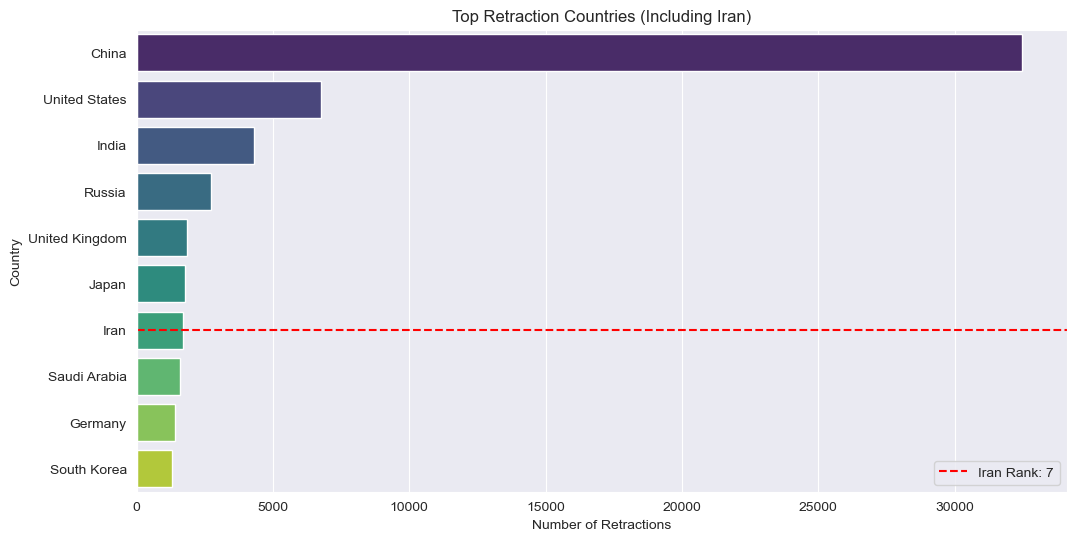

Iran's Rank: 7 out of 182 countries


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Iran is in the dataset
iran_count = country_counts.get("Iran", 0)
iran_rank = sorted(country_counts.values(), reverse=True).index(iran_count) + 1

# Top 10 countries (Ensure Iran is included)
top_countries_df = country_counts_df.head(10)

# If Iran is not in the top 10, add it manually for comparison
if "Iran" not in top_countries_df["Country"].values:
    iran_row = country_counts_df[country_counts_df["Country"] == "Iran"]
    top_countries_df = pd.concat([top_countries_df, iran_row])

# Bar Plot for Top Countries
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries_df, x="Count", y="Country", palette="viridis")
plt.axhline(y=iran_rank - 1, color='red', linestyle="--", label=f"Iran Rank: {iran_rank}")
plt.xlabel("Number of Retractions")
plt.ylabel("Country")
plt.title("Top Retraction Countries (Including Iran)")
plt.legend()
plt.show()

# Display Iran's ranking
print(f"Iran's Rank: {iran_rank} out of {len(country_counts)} countries")


C:\Users\Parsa\AppData\Local\Temp\ipykernel_5204\3644542881.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries_df, x="Retraction_Rate", y="Country", palette="mako")


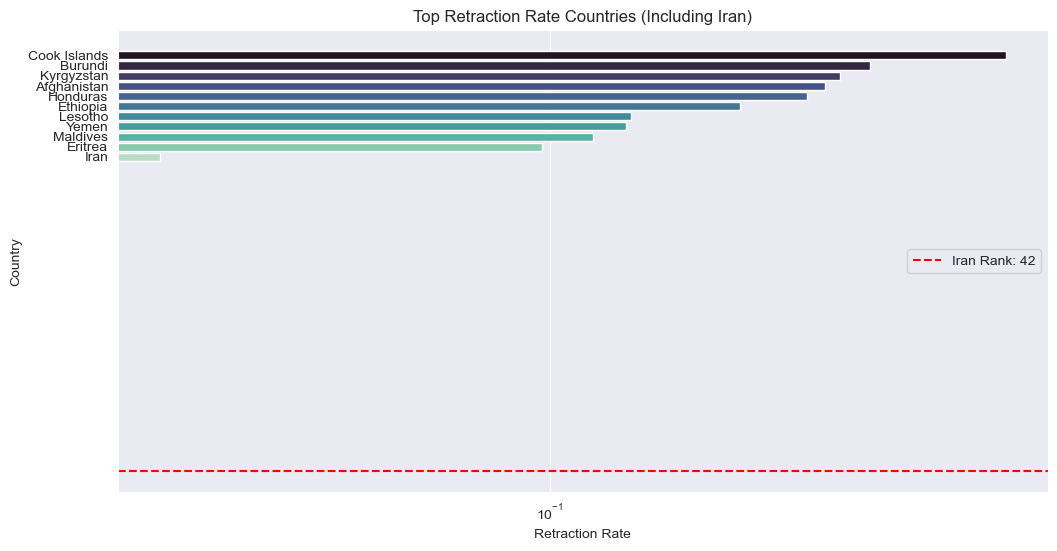

Iran's Retraction Rate Rank: 42 out of 113 countries


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Iran is in the dataset
iran_data = merged_data[merged_data["Country"] == "Iran"]
iran_rate = iran_data["Retraction_Rate"].values[0] if not iran_data.empty else 0
iran_rank = merged_data["Retraction_Rate"].rank(ascending=False, method="min")[merged_data["Country"] == "Iran"].values[0]

# Select top 10 countries by retraction rate
top_countries_df = merged_data.nlargest(10, "Retraction_Rate")

# If Iran is not in the top 10, add it manually for comparison
if "Iran" not in top_countries_df["Country"].values:
    top_countries_df = pd.concat([top_countries_df, iran_data])

# Sort data for better visualization
top_countries_df = top_countries_df.sort_values(by="Retraction_Rate", ascending=False)

# Bar Plot for Retraction Rate
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries_df, x="Retraction_Rate", y="Country", palette="mako")

# Highlight Iran
plt.axhline(y=iran_rank - 1, color='red', linestyle="--", label=f"Iran Rank: {int(iran_rank)}")
plt.xlabel("Retraction Rate")
plt.ylabel("Country")
plt.title("Top Retraction Rate Countries (Including Iran)")
plt.xscale("log")  # Use log scale if values vary significantly
plt.legend()
plt.show()

# Display Iran's ranking
print(f"Iran's Retraction Rate Rank: {int(iran_rank)} out of {len(merged_data)} countries")


C:\Users\Parsa\AppData\Local\Temp\ipykernel_5204\3499973207.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries_df, x="Retraction_Rate", y="Country", palette="coolwarm")


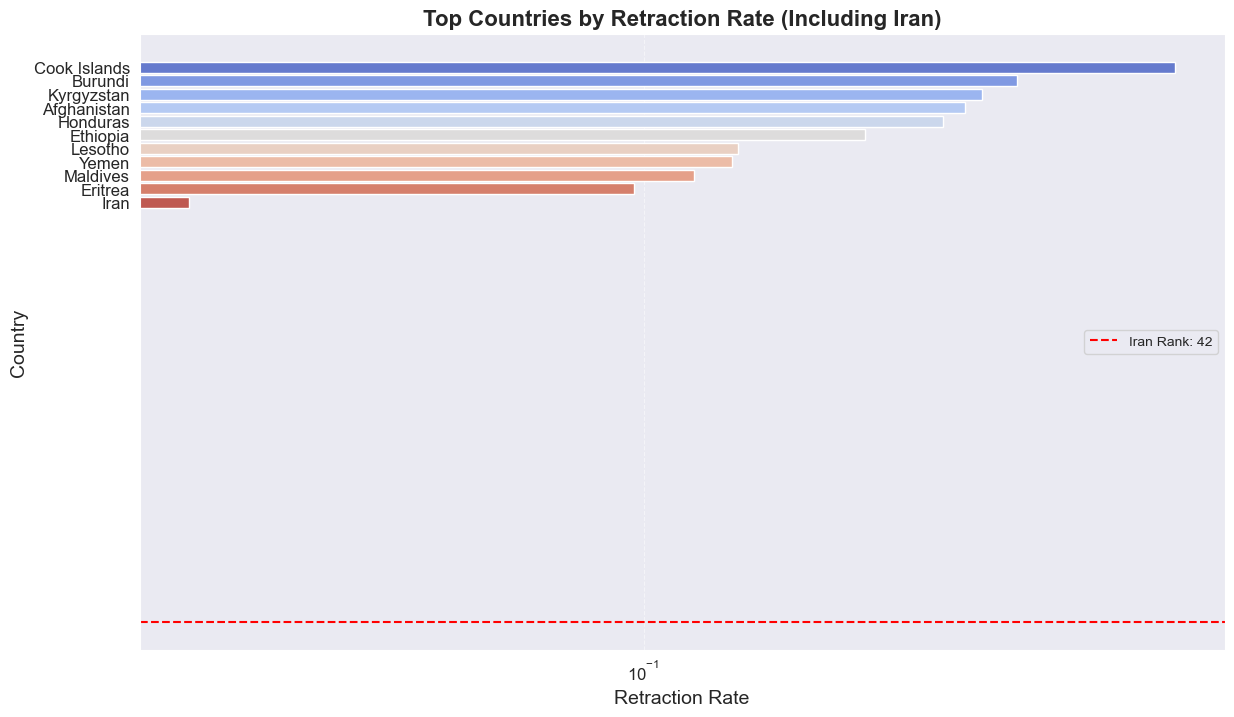

Iran's Retraction Rate Rank: 42 out of 113 countries


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Ensure Iran is in the dataset
iran_data = merged_data[merged_data["Country"] == "Iran"]
iran_rate = iran_data["Retraction_Rate"].values[0] if not iran_data.empty else 0
iran_rank = merged_data["Retraction_Rate"].rank(ascending=False, method="min")[merged_data["Country"] == "Iran"].values[0]

# Select top 10 countries by retraction rate
top_countries_df = merged_data.nlargest(10, "Retraction_Rate")

# If Iran is not in the top 10, add it manually
if "Iran" not in top_countries_df["Country"].values:
    top_countries_df = pd.concat([top_countries_df, iran_data])

# Sort data
top_countries_df = top_countries_df.sort_values(by="Retraction_Rate", ascending=False)

# Shorten long country names
top_countries_df["Country"] = top_countries_df["Country"].apply(lambda x: "\n".join(textwrap.wrap(x, width=15)))

# Plot
plt.figure(figsize=(14, 8))  # Larger figure size
sns.barplot(data=top_countries_df, x="Retraction_Rate", y="Country", palette="coolwarm")

# Highlight Iran
plt.axhline(y=iran_rank - 1, color='red', linestyle="--", label=f"Iran Rank: {int(iran_rank)}")

# Labels & Title
plt.xlabel("Retraction Rate", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.title("Top Countries by Retraction Rate (Including Iran)", fontsize=16, fontweight="bold")

# Improve layout
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xscale("log")  # Log scale for better visibility
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

# Display Iran's ranking
print(f"Iran's Retraction Rate Rank: {int(iran_rank)} out of {len(merged_data)} countries")


C:\Users\Parsa\AppData\Local\Temp\ipykernel_5204\769365281.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")


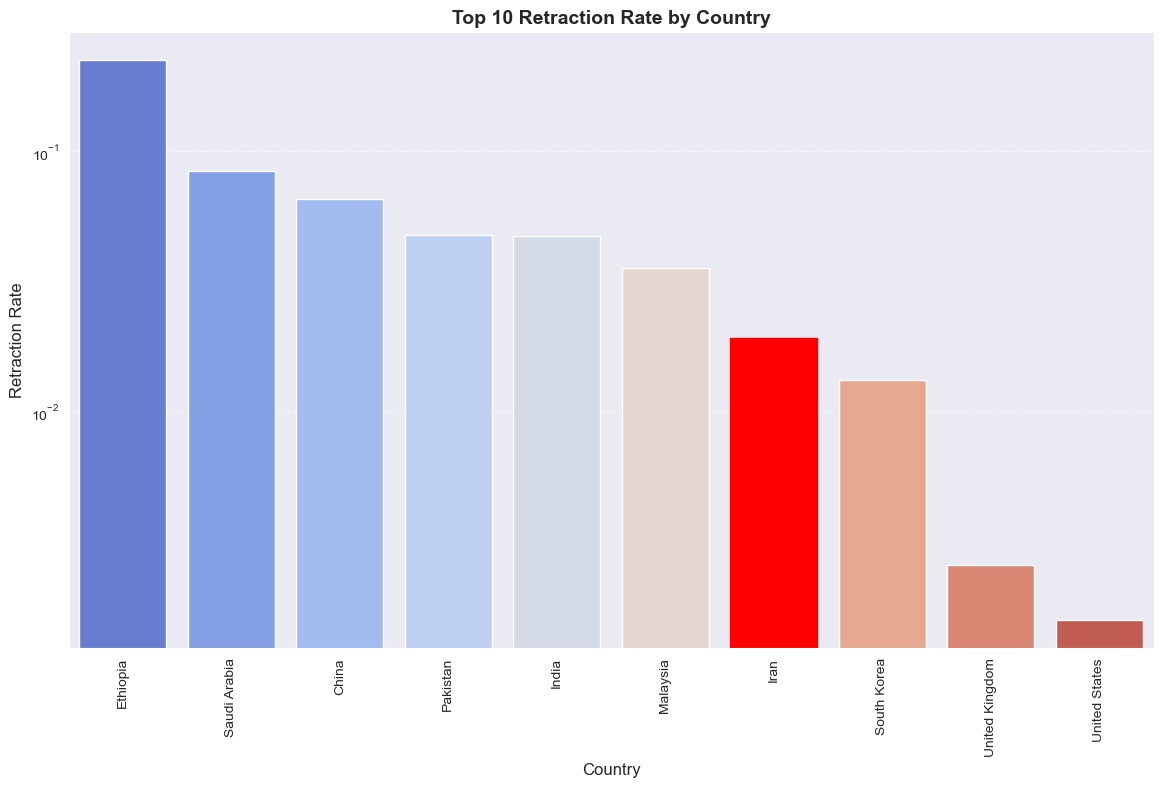

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate
sorted_data = merged_data.head(10).sort_values(by="Retraction_Rate", ascending=False)

# Increase figure size
plt.figure(figsize=(14, 8))

# Create the barplot
bars = sns.barplot(data=sorted_data, x="Country", y="Retraction_Rate", palette="coolwarm")

# Highlight Iran
for bar, country in zip(bars.patches, sorted_data["Country"]):
    if country == "Iran":
        bar.set_color("red")  # Change color for Iran

# Rotate x-axis labels for readability
plt.xticks(rotation=90, fontsize=10)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Retraction Rate", fontsize=12)
plt.title("Top 10 Retraction Rate by Country", fontsize=14, fontweight="bold")

# Use log scale to handle large differences
plt.yscale("log")

# Grid for better visualization
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Show the plot
plt.show()


C:\Users\Parsa\AppData\Local\Temp\ipykernel_5204\1864498160.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=top_20_countries, x="Country", y="Retraction_Rate", palette="coolwarm")


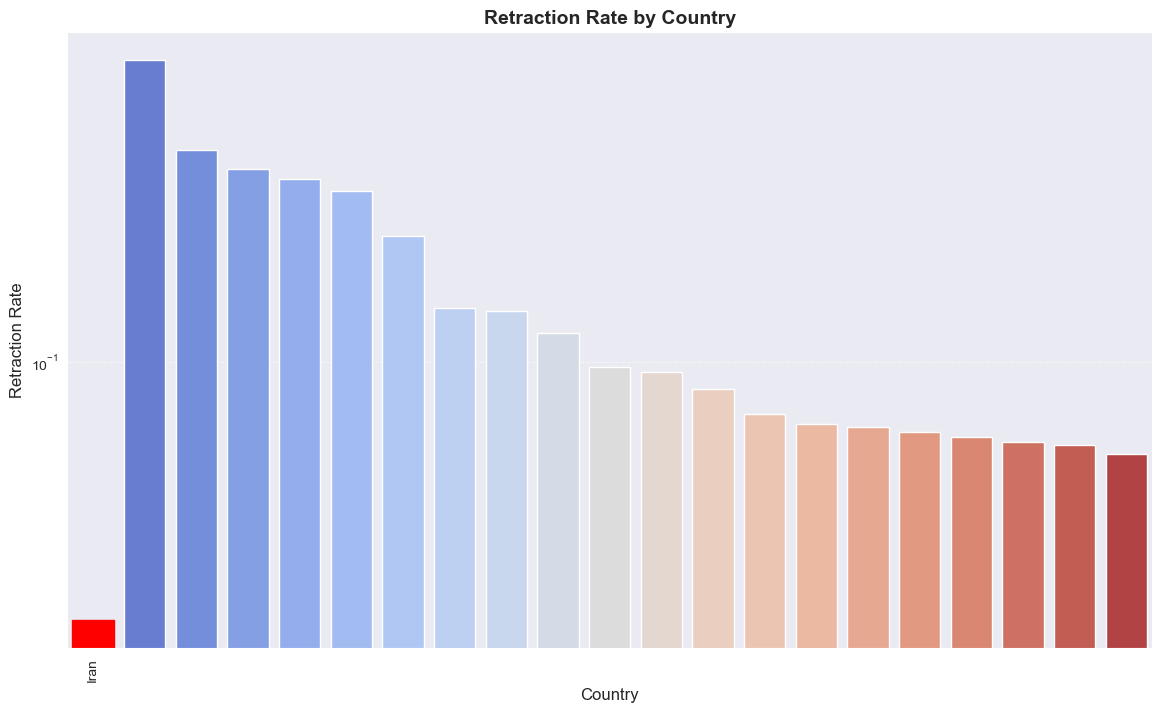

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by retraction rate
sorted_data = merged_data.sort_values(by="Retraction_Rate", ascending=False)

# Get the top 20 countries and include Iran
top_20_countries = sorted_data.head(20)
iran_row = sorted_data[sorted_data["Country"] == "Iran"]
top_20_countries = pd.concat([iran_row, top_20_countries]).drop_duplicates()

# Increase figure size
plt.figure(figsize=(14, 8))

# Create the barplot
bars = sns.barplot(data=top_20_countries, x="Country", y="Retraction_Rate", palette="coolwarm")

# Highlight Iran
for bar, country in zip(bars.patches, top_20_countries["Country"]):
    if country == "Iran":
        bar.set_color("red")  # Change color for Iran

# Rotate x-axis labels for readability
plt.xticks(rotation=90, fontsize=10)

# Remove country names for countries other than Iran
labels = [country if country == "Iran" else "" for country in top_20_countries["Country"]]
plt.xticks(ticks=plt.gca().get_xticks(), labels=labels, fontsize=10)

# Add labels and title
plt.xlabel("Country", fontsize=12)
plt.ylabel("Retraction Rate", fontsize=12)
plt.title("Retraction Rate by Country", fontsize=14, fontweight="bold")

# Use log scale to handle large differences
plt.yscale("log")

# Grid for better visualization
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Show the plot
plt.show()
